In [1]:
import sys
sys.path.append('/disk1/cai029/project/jupyter_notebook/CauFinder-main-main/')
import CauFinder

In [2]:
import os
from math import ceil, floor
from typing import Dict, List, Optional, Union
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from statistics import stdev
from numpy import nanstd, isnan, nan
import random
from scipy import linalg
import torch
from anndata import AnnData, concat
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from CauFinder.dataloader import zscore_normalization, apply_activation
from CauFinder.benchmark import run_caufinder121
import chardet
from CauFinder.caufinder_main import CausalFinder
from CauFinder.benchmark import cumulative_weight_sum_rate
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.decomposition import PCA
from CauFinder.utils import set_seed, plot_feature_boxplots, merge_basic_driver, merge_complex_driver
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from CauFinder.utils import load_luas_human_adata, human_all_adata, human_data_direction, calculate_w1_w2, find_index
from CauFinder.utils import result_add_direction, plot_control_scores, plot_control_scores_by_category
from CauFinder.utils import plot_3d_state_transition, plot_causal_feature_transitions
import umap

import scanpy as sc
import pickle as pkl
import collections as ct
import warnings

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
2025-10-29 16:45:53.985507: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-29 16:45:54.960568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-29 16:45:55.121403: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-29 16:45:55.151154: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory f

In [3]:
import scanpy as sc

In [4]:
warnings.filterwarnings("ignore")
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

In [5]:
BASE_DIR = '/disk1/cai029/Caufussion/Benchmark_driver/Methods/Caufinder/'

#训练模型保存到的文件夹路径
output_path = os.path.join(BASE_DIR, 'output')
print(output_path)
if not os.path.exists(output_path):
    os.makedirs(output_path, exist_ok=True)
else:
    print("This folders already exists") 

/disk1/cai029/Caufussion/Benchmark_driver/Methods/Caufinder/output
This folders already exists


In [6]:
#根据转录因子文本文件hs_hgnc_tfs_lambert2018.txt来读取一个包含转录因子列表
tf_path = os.path.join(BASE_DIR,'TF_names_v_1.01.txt')
tf_df = pd.read_csv(tf_path, header=None)

# 将第一列（默认为0）转换为列表
tf_list = tf_df[0].tolist()

print(len(tf_list), tf_list)

1639 ['AC008770.3', 'AC023509.3', 'AC092835.1', 'AC138696.1', 'ADNP', 'ADNP2', 'AEBP1', 'AEBP2', 'AHCTF1', 'AHDC1', 'AHR', 'AHRR', 'AIRE', 'AKAP8', 'AKAP8L', 'AKNA', 'ALX1', 'ALX3', 'ALX4', 'ANHX', 'ANKZF1', 'AR', 'ARGFX', 'ARHGAP35', 'ARID2', 'ARID3A', 'ARID3B', 'ARID3C', 'ARID5A', 'ARID5B', 'ARNT', 'ARNT2', 'ARNTL', 'ARNTL2', 'ARX', 'ASCL1', 'ASCL2', 'ASCL3', 'ASCL4', 'ASCL5', 'ASH1L', 'ATF1', 'ATF2', 'ATF3', 'ATF4', 'ATF5', 'ATF6', 'ATF6B', 'ATF7', 'ATMIN', 'ATOH1', 'ATOH7', 'ATOH8', 'BACH1', 'BACH2', 'BARHL1', 'BARHL2', 'BARX1', 'BARX2', 'BATF', 'BATF2', 'BATF3', 'BAZ2A', 'BAZ2B', 'BBX', 'BCL11A', 'BCL11B', 'BCL6', 'BCL6B', 'BHLHA15', 'BHLHA9', 'BHLHE22', 'BHLHE23', 'BHLHE40', 'BHLHE41', 'BNC1', 'BNC2', 'BORCS8-MEF2B', 'BPTF', 'BRF2', 'BSX', 'C11orf95', 'CAMTA1', 'CAMTA2', 'CARF', 'CASZ1', 'CBX2', 'CC2D1A', 'CCDC169-SOHLH2', 'CCDC17', 'CDC5L', 'CDX1', 'CDX2', 'CDX4', 'CEBPA', 'CEBPB', 'CEBPD', 'CEBPE', 'CEBPG', 'CEBPZ', 'CENPA', 'CENPB', 'CENPBD1', 'CENPS', 'CENPT', 'CENPX', 'CGGBP

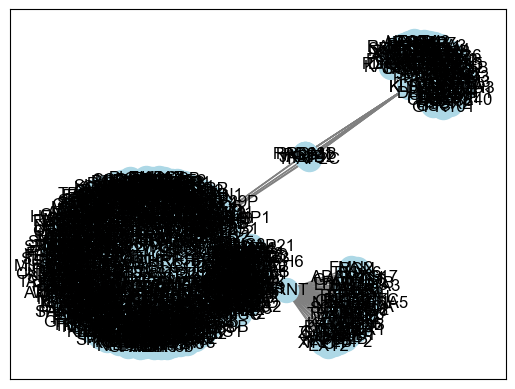

In [7]:
#NicheNet_human.csv这个文件构建先验网络
network_path = os.path.join(BASE_DIR,'network_human.csv')
prior_network = pd.read_csv(network_path, index_col=None, header=0)
part_network = prior_network.iloc[0:1000]

#绘制先验网络图
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = part_network
G = nx.from_pandas_edgelist(df, 'from', 'to')

pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

In [8]:
adata = sc.read_h5ad("/disk1/cai029/Caufussion/Benchmark_driver/Dataset/all_data.h5ad")

In [9]:
import numpy as np
combined_data = pd.DataFrame(adata.X.toarray(),
                  index=adata.obs_names.tolist(),
                  columns=adata.var_names.tolist())

In [10]:
combined_data

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,AAAS,AACS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
AML916-D0_AAAAATTTCCCN-0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
AML916-D0_AAAATATTACCT-0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.652384,0.0,0.0,0.0,1.652384,0.0,0.0,0.0,0.0,0.0
AML916-D0_AAACCCCCCCAC-0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
AML916-D0_AAACGATCGAAC-0,2.036303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
AML916-D0_AAAGAGAGCCCT-0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BM2_CGGAGGCTGGAN-21,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
BM2_TCTAGGGACGCA-21,3.125474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
BM2_CTACGTTTCGCT-21,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
BM2_AGCTACGATTTG-21,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [11]:
adata = AnnData(combined_data)
adata

AnnData object with n_obs × n_vars = 22599 × 20718

In [12]:
condition_dict = {'A':"AML",'B':"HEALTH"}
label_dict = {'AML':1 , 'HEALTH':0}
conditions = [condition_dict[obs_name[0]] for obs_name in adata.obs_names.tolist()]
labels = [label_dict[condition] for condition in conditions]
adata.obs['condition'] = conditions
adata.obs['labels'] = labels
adata.obs

,condition,labels
AML916-D0_AAAAATTTCCCN-0,AML,1
AML916-D0_AAAATATTACCT-0,AML,1
AML916-D0_AAACCCCCCCAC-0,AML,1
AML916-D0_AAACGATCGAAC-0,AML,1
AML916-D0_AAAGAGAGCCCT-0,AML,1
...,...,...
BM2_CGGAGGCTGGAN-21,HEALTH,0
BM2_TCTAGGGACGCA-21,HEALTH,0
BM2_CTACGTTTCGCT-21,HEALTH,0
BM2_AGCTACGATTTG-21,HEALTH,0


In [13]:
# condition_dict = {0:'HEALTH',1:'VEXAS'}
# adata.obs['condition'] = [condition_dict[i] for i in adata.obs['stage'].tolist()]
# adata.obs['labels'] = adata.obs['stage']

In [14]:
def calculate_deg(adata, group1_label='HEALTH', group2_label='AML', alpha=0.05, fc_threshold=1.2):
    """
    Calculate DEGs using Mann-Whitney U test, considering fold change threshold.
    使用Mann-Whitney U检验计算差异表达基因，同时考虑折叠变化阈值。
    """
    # 提取两组的表达数据
    group1_data = adata[adata.obs['condition'] == group1_label].X
    print('HEALTH shape:',group1_data.shape)
    group2_data = adata[adata.obs['condition'] == group2_label].X
    print('VEXAS shape:',group2_data.shape)
    
    
    # 在adata.var中初始化列以存储结果
    adata.var['p_value'] = np.nan
    adata.var['fold_change'] = np.nan
    adata.var['is_deg'] = False

    # 遍历每个基因
    for gene_idx, gene_name in enumerate(adata.var_names):
        expr1 = group1_data[:, gene_idx]
        expr2 = group2_data[:, gene_idx]
        # 执行Mann-Whitney U检验
        # 检验两个独立样本是否来自同一分布
        _, p_value = mannwhitneyu(expr1, expr2, alternative='two-sided')

        # 计算折叠变化（group2的平均值 / group1的平均值）
        # 加上1e-6防止分母为0
        fc = np.mean(expr2) / np.mean(expr1 + 1e-6)

        # 更新adata.var中的结果
        adata.var.at[gene_name, 'p_value'] = p_value
        adata.var.at[gene_name, 'fold_change'] = fc
        # 根据p值和折叠变化阈值判断基因是否为差异表达基因
        is_deg = (p_value < alpha) and ((fc >= fc_threshold) or (fc <= 1 / fc_threshold))
        adata.var.at[gene_name, 'is_deg'] = is_deg

    # 返回更新后的adata对象
    return adata

adata = calculate_deg(adata, group1_label='HEALTH', group2_label='AML', alpha=0.05, fc_threshold=1.2)
print("adata根据上述数据，判断基因是否为差异表达基因为：\n",adata.var)
print("输入的数据矩阵中为差异基因的数量为:",adata.var[adata.var['is_deg']==True].shape[0])

HEALTH shape: (6914, 20718)
VEXAS shape: (15685, 20718)
adata根据上述数据，判断基因是否为差异表达基因为：
                p_value  fold_change  is_deg
A1BG      2.831895e-10     1.512287    True
A1BG-AS1  8.074387e-01     1.214006   False
A1CF      3.715633e-01     1.922831   False
A2M       4.406140e-01     0.767532   False
A2M-AS1   8.127882e-01     0.790924   False
...                ...          ...     ...
ZYG11A    2.437104e-01     1.301854   False
ZYG11B    2.936369e-06     0.884231   False
ZYX       5.304829e-63     2.658319    True
ZZEF1     5.494182e-01     1.122377   False
ZZZ3      5.424853e-12     0.808246    True

[20718 rows x 3 columns]
输入的数据矩阵中为差异基因的数量为: 8480


In [15]:
features_mask = adata.var['is_deg'] 
samples_mask = (adata.obs['condition'] == 'HEALTH') | (adata.obs['condition'] == 'AML')
adata_filter = adata[samples_mask, features_mask].copy()

In [16]:
model = CausalFinder(
        adata=adata_filter,
        n_latent=50,
        n_causal=10,
        n_hidden=256,
        n_layers_encoder=0,
        n_layers_decoder=0,
        n_layers_dpd=0,
        dropout_rate_encoder=0.0,
        dropout_rate_decoder=0.0,
        dropout_rate_dpd=0.0,
        use_batch_norm='none',
        use_batch_norm_dpd=True,
        pdp_linear=True,
    )

model.train(max_epochs=400, stage_training=True)

training: 100%|█████████████████████████████████████████| 400/400 [2:44:02<00:00, 24.61s/it]


In [17]:
import pickle
import os
model_path = os.path.join('/disk1/cai029/Caufussion/Benchmark_driver/Methods/Caufinder/9.train_model_seed60.pkl')
# 保存模型
with open(model_path, 'wb') as file:
    pickle.dump(model, file)

In [16]:
import pickle
import os
model_path = os.path.join('/disk1/cai029/Caufussion/Benchmark_driver/Methods/Caufinder/4.train_model_seed60.pkl')
# 保存模型
with open(model_path, 'rb') as file:
    model = pickle.load(file)

In [18]:
# SHAP
weight_shap_total, weight_shap_full = model.get_feature_weights(sort_by_weight=True, method="SHAP")
weight_shap_0, weight_shap_1 = model.get_class_weights(weight_shap_full, sort_by_weight=True)

In [19]:
# Grad
# weight_grad_total, weight_grad_full = model.get_feature_weights(sort_by_weight=True, method="Grad")
# weight_grad_0, weight_grad_1 = model.get_class_weights(weight_grad_full, sort_by_weight=True)
# Class driver (SHAP or Grad for each class)
driver_df = model.network_master_regulators(prior_network, weight_shap_total, corr_cutoff=0.7, out_lam=1.0, ILP_lam=0.5)
driver_total = driver_df[driver_df['is_CauFVS_driver']].index.tolist()
driver_df = model.network_master_regulators(prior_network, weight_shap_0, corr_cutoff=0.7, out_lam=1.0, ILP_lam=0.5)
driver_0 = driver_df[driver_df['is_CauFVS_driver']].index.tolist()
driver_df = model.network_master_regulators(prior_network, weight_shap_1, corr_cutoff=0.7, out_lam=1.0, ILP_lam=0.5)
driver_1 = driver_df[driver_df['is_CauFVS_driver']].index.tolist()

Adding 4 additional edges to the network
Number of nodes: 5497
Number of edges: 78727
Identifying driver regulators...
Set parameter Username
Set parameter LicenseID to value 2589397
Academic license - for non-commercial use only - expires 2025-11-24
  Solving MFVS problem...
    300 critical nodes are found.
    477 nodes left after graph reduction operation.
    Solving the Integer Linear Programming problem on the reduced graph...
      Solving by GUROBI...(optimal value with GUROBI:71.9579934218994,  status:optimal)
  372 MFVS driver nodes are found.
  50 top-rank genes are found.
The number of causal FVS driver: 37
Adding 4 additional edges to the network
Number of nodes: 5497
Number of edges: 78727
Identifying driver regulators...
  Solving MFVS problem...
    300 critical nodes are found.
    477 nodes left after graph reduction operation.
    Solving the Integer Linear Programming problem on the reduced graph...
      Solving by GUROBI...(optimal value with GUROBI:71.9577261657

In [20]:
# 检查 prior_network 的列名
print("prior_network 列名:", prior_network.columns)

# 检查 prior_network 的索引名
print("prior_network 索引名:", prior_network.index.name)

prior_network 列名: Index(['from', 'to', 'edge_type'], dtype='object')
prior_network 索引名: None


In [21]:
# 检查 adata 的基因名称（行名）
print("adata 行名（基因名）:", adata.var_names.name)
print("前5个基因名:", adata.var_names[:5])

# 检查 adata 的列名（通常是细胞/样本）
print("adata 列名:", adata.obs_names.name)
print("前5个样本名:", adata.obs_names[:5])

adata 行名（基因名）: None
前5个基因名: Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1'], dtype='object')
adata 列名: None
前5个样本名: Index(['AML916-D0_AAAAATTTCCCN-0', 'AML916-D0_AAAATATTACCT-0',
       'AML916-D0_AAACCCCCCCAC-0', 'AML916-D0_AAACGATCGAAC-0',
       'AML916-D0_AAAGAGAGCCCT-0'],
      dtype='object')


In [22]:
driver_df.to_csv('/disk1/cai029/Caufussion/Benchmark_driver/Methods/Caufinder/output/9_driver_df.csv')

In [23]:
driver_df

,score,is_MFVS_driver,is_CauFVS_driver,is_CauW_driver
TCF4,7.797564e-03,True,True,True
IRF8,7.346912e-03,True,True,True
HMGB2,7.287804e-03,False,False,True
SMC3,6.437765e-03,True,True,True
JUND,5.950676e-03,True,True,True
...,...,...,...,...
LDHB,5.716462e-09,True,False,False
ACTG1,3.813734e-09,True,False,False
HSP90AB1,3.540848e-09,True,False,False
DEK,3.145187e-09,True,False,False
